# 04 – Evaluation & Reporting

**PM2.5 Time Series: Factor Analysis & SARIMA**  
Notebook này triển khai **Step 4 – Đánh giá mô hình** dựa trên logic trong `src/evaluation.py`.

## Mục tiêu

- Load mô hình SARIMA đã lưu (`data/processed/sarima_model.joblib`).
- Load fa_data, gộp theo ngày, chia train/test **giống Step 3** để có cùng `y_test` và `exog_test`.
- **Dự báo** trên test set: `model.predict(n_periods=len(y_test), X=exog_test)`.
- Tính **RMSE, MAE, MAPE** và lưu vào `reports/tables/evaluation_metrics.csv`.
- Vẽ **Actual vs Predicted** → `reports/figures/04_eval/actual_vs_predicted.png`.
- **Chẩn đoán phần dư**: histogram, Q-Q plot, kiểm định Ljung-Box → `residual_diagnostics.png`.
- (Tùy chọn) Lưu dữ liệu demo cho Streamlit: `demo_predictions.csv`, `demo_residuals.csv`, `demo_params.json`.

## Các lệnh / bước chính

| Bước | Lệnh / Hàm | Mô tả ngắn |
|------|------------|------------|
| 1 | `joblib.load(path)` | Load bundle mô hình (model + exog_cols, seasonal_period) |
| 2 | `load_fa_data` + `aggregate_to_daily` + `train_test_split` | Chuẩn bị y_test, exog_test giống Step 3 |
| 3 | `model.predict(n_periods=..., X=exog_test)` | Dự báo từng bước trên test |
| 4 | RMSE/MAE/MAPE (numpy) | Đánh giá sai số |
| 5 | `plot_actual_vs_predicted` | Đồ thị Actual vs Predicted |
| 6 | `model.resid()` | Phần dư (training) |
| 7 | `acorr_ljungbox`, `qqplot`, histogram | Chẩn đoán phần dư, lưu figure |

## Điều kiện trước khi chạy

- Đã có `data/processed/sarima_model.joblib` (tạo từ Step 3 / `03_sarima_model.ipynb` hoặc `python src/sarima_model.py`).
- Đã có `data/processed/fa_data.csv` (từ Step 2).

## Thiết lập môi trường

- Project root và thư mục: `PROCESSED_DIR`, `EVAL_FIG`, `TABLES_DIR`.
- Thư viện: `pandas`, `numpy`, `matplotlib`, `joblib`, `statsmodels` (qqplot, acorr_ljungbox).
- Hằng số: `FACTOR_COLS`, `TEST_RATIO` (phải trùng với Step 3, mặc định 0.2).

In [1]:
# Thiết lập môi trường
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
EVAL_FIG = ROOT / "reports" / "figures" / "04_eval"
TABLES_DIR = ROOT / "reports" / "tables"

for p in [PROCESSED_DIR, EVAL_FIG, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
pd.set_option("display.max_columns", 50)

FACTOR_COLS = ["Factor1", "Factor2", "Factor3"]
TEST_RATIO = 0.2  # phải trùng với Step 3

print("ROOT:", ROOT)
print("Model:", PROCESSED_DIR / "sarima_model.joblib")
print("Figures:", EVAL_FIG)

ROOT: E:\myself\GITHUB\pm25_sarima_project
Model: E:\myself\GITHUB\pm25_sarima_project\data\processed\sarima_model.joblib
Figures: E:\myself\GITHUB\pm25_sarima_project\reports\figures\04_eval


## 1. Load mô hình SARIMA

**Lệnh:** `joblib.load(path)`  
- File lưu là một **dict**: `model` (đối tượng ARIMA đã fit), `exog_cols`, `seasonal_period`.  
- Dùng `bundle["model"]` để gọi `predict`, `resid`.

In [2]:
model_path = PROCESSED_DIR / "sarima_model.joblib"
if not model_path.exists():
    raise FileNotFoundError(f"Thiếu {model_path}. Hãy chạy Step 3 (SARIMA) trước.")

bundle = joblib.load(model_path)
model = bundle["model"]

print("Order (p,d,q):", model.order)
print("Seasonal order:", model.seasonal_order)
print("exog_cols trong bundle:", bundle.get("exog_cols"))

Order (p,d,q): (2, 1, 1)
Seasonal order: (1, 0, 0, 7)
exog_cols trong bundle: ['Factor1', 'Factor2', 'Factor3']


## 2. Chuẩn bị dữ liệu test (fa_data → daily → train/test split)

**Lệnh:**  
- `pd.read_csv(fa_data.csv, index_col=0, parse_dates=True)`  
- `df[numeric_cols].resample("D").mean()` → gộp theo ngày.  
- Chia theo thời gian: 80% train, 20% test → `y_train`, `y_test`, `exog_train`, `exog_test`.  

Cách chia **phải giống Step 3** (cùng `TEST_RATIO`) để so sánh công bằng.

In [3]:
fa_path = PROCESSED_DIR / "fa_data.csv"
if not fa_path.exists():
    raise FileNotFoundError(f"Thiếu {fa_path}. Hãy chạy Step 2 trước.")

df = pd.read_csv(fa_path, index_col=0, parse_dates=True)
numeric_cols = df.select_dtypes(include="number").columns.tolist()
daily = df[numeric_cols].resample("D").mean().dropna(how="all")

n = len(daily)
split_idx = int(n * (1 - TEST_RATIO))
train_df = daily.iloc[:split_idx]
test_df = daily.iloc[split_idx:]

y_train = train_df["PM2.5"]
y_test = test_df["PM2.5"]
exog_cols = [c for c in FACTOR_COLS if c in daily.columns]
exog_train = train_df[exog_cols] if exog_cols else None
exog_test = test_df[exog_cols] if exog_cols else None

print("Train:", len(y_train), "ngày | Test:", len(y_test), "ngày")
print("exog:", exog_cols if exog_cols else "Không")

Train: 1168 ngày | Test: 293 ngày
exog: ['Factor1', 'Factor2', 'Factor3']


## 3. Dự báo trên test set

**Lệnh:** `model.predict(n_periods=len(y_test), X=exog_test.values)`  
- **n_periods**: số bước dự báo (bằng số ngày test).  
- **X**: ma trận ngoại sinh tương ứng từng bước; phải có shape `(len(y_test), n_factors)`.  
- Kết quả là mảng 1 chiều (predicted PM2.5 cho từng ngày test).

In [4]:
exog_test_arr = exog_test.values if exog_test is not None else None
y_pred = model.predict(n_periods=len(y_test), X=exog_test_arr)

print("Số điểm dự báo:", len(y_pred))
print("Ví dụ 5 giá trị đầu:", y_pred[:5])

Số điểm dự báo: 293
Ví dụ 5 giá trị đầu: 2016-05-12    63.667200
2016-05-13    46.781249
2016-05-14    34.034600
2016-05-15    32.356651
2016-05-16    53.611899
Freq: D, dtype: float64


## 4. Tính chỉ số đánh giá (RMSE, MAE, MAPE)

**Công thức:**  
- **RMSE** = √(mean((y_true - y_pred)²))  
- **MAE** = mean(|y_true - y_pred|)  
- **MAPE** = mean(|y_true - y_pred| / (|y_true| + ε)) × 100% (tránh chia 0).  

Lọc bỏ cặp (y_true, y_pred) có NaN trước khi tính.

In [5]:
y_true = np.asarray(y_test.values).flatten()
y_pred_arr = np.asarray(y_pred).flatten()
mask = ~(np.isnan(y_true) | np.isnan(y_pred_arr))
y_t, y_p = y_true[mask], y_pred_arr[mask]

rmse = np.sqrt(np.mean((y_t - y_p) ** 2))
mae = np.mean(np.abs(y_t - y_p))
mape = np.mean(np.abs((y_t - y_p) / (y_t + 1e-10))) * 100

metrics = {"RMSE": rmse, "MAE": mae, "MAPE": mape}
print("RMSE:", f"{metrics['RMSE']:.4f}")
print("MAE:", f"{metrics['MAE']:.4f}")
print("MAPE:", f"{metrics['MAPE']:.2f}%")

metrics_path = TABLES_DIR / "evaluation_metrics.csv"
pd.DataFrame([metrics]).to_csv(metrics_path, index=False)
print("Đã lưu:", metrics_path)

RMSE: 37.7537
MAE: 30.0790
MAPE: 69.71%
Đã lưu: E:\myself\GITHUB\pm25_sarima_project\reports\tables\evaluation_metrics.csv


## 5. Đồ thị Actual vs Predicted

**Lệnh:** Vẽ hai đường theo index (ngày): `y_test` (Actual) và `y_pred` (Predicted).  
Lưu vào `reports/figures/04_eval/actual_vs_predicted.png`.

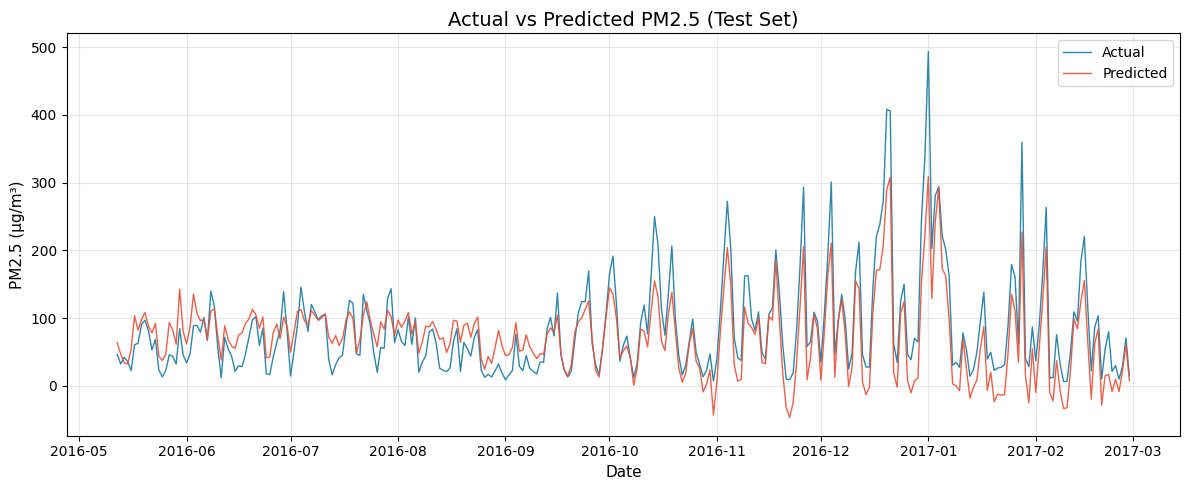

Đã lưu: E:\myself\GITHUB\pm25_sarima_project\reports\figures\04_eval\actual_vs_predicted.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_test.index, y_test.values, label="Actual", color="#2E86AB", linewidth=1)
ax.plot(y_test.index, y_pred, label="Predicted", color="#E94F37", linewidth=1, alpha=0.9)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("PM2.5 (μg/m³)", fontsize=11)
ax.set_title("Actual vs Predicted PM2.5 (Test Set)", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

out_path = EVAL_FIG / "actual_vs_predicted.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print("Đã lưu:", out_path)

## 6. (Tùy chọn) Lưu dữ liệu demo cho Streamlit

**Lệnh:**  
- `model.predict(..., return_conf_int=True, alpha=0.05)` → dự báo kèm khoảng tin cậy 95%.  
- Lưu `date`, `actual`, `predicted`, `ci_low`, `ci_high` → `data/processed/demo_predictions.csv`.  
- Lưu phần dư (training) → `demo_residuals.csv`.  
- Lưu `order`, `seasonal_order` → `demo_params.json`.  

Nếu có lỗi (ví dụ mô hình không hỗ trợ return_conf_int đúng cách) thì bỏ qua bước này.

In [7]:
import json

try:
    pred, conf = model.predict(
        n_periods=len(y_test),
        X=exog_test.values if exog_test is not None else None,
        return_conf_int=True,
        alpha=0.05,
    )
    res = model.resid()
    res_flat = np.asarray(res).flatten()[:5000]

    pd.DataFrame({
        "date": y_test.index,
        "actual": y_test.values,
        "predicted": pred,
        "ci_low": conf[:, 0],
        "ci_high": conf[:, 1],
    }).to_csv(PROCESSED_DIR / "demo_predictions.csv", index=False)
    pd.DataFrame({"residual": res_flat}).to_csv(PROCESSED_DIR / "demo_residuals.csv", index=False)
    with open(PROCESSED_DIR / "demo_params.json", "w") as f:
        json.dump({
            "order": list(model.order),
            "seasonal_order": list(model.seasonal_order),
        }, f)
    print("Đã lưu demo_predictions.csv, demo_residuals.csv, demo_params.json vào", PROCESSED_DIR)
except Exception as e:
    print("Không lưu được demo data:", e)

Đã lưu demo_predictions.csv, demo_residuals.csv, demo_params.json vào E:\myself\GITHUB\pm25_sarima_project\data\processed


## 7. Chẩn đoán phần dư (Residual diagnostics)

**Lệnh:**  
- **Phần dư:** `model.resid()` — phần dư trên tập huấn luyện.  
- **Histogram:** phân bố phần dư (kỳ vọng gần chuẩn, trung tâm 0).  
- **Q-Q plot:** `qqplot(residuals, line='45')` — kiểm tra tính chuẩn.  
- **Ljung-Box:** `acorr_ljungbox(residuals, lags=range(1, 16), return_df=True)` — kiểm tra tự tương quan phần dư (p-value > 0.05 mong muốn ở các lag).  

Lưu figure 3 ô vào `reports/figures/04_eval/residual_diagnostics.png`.

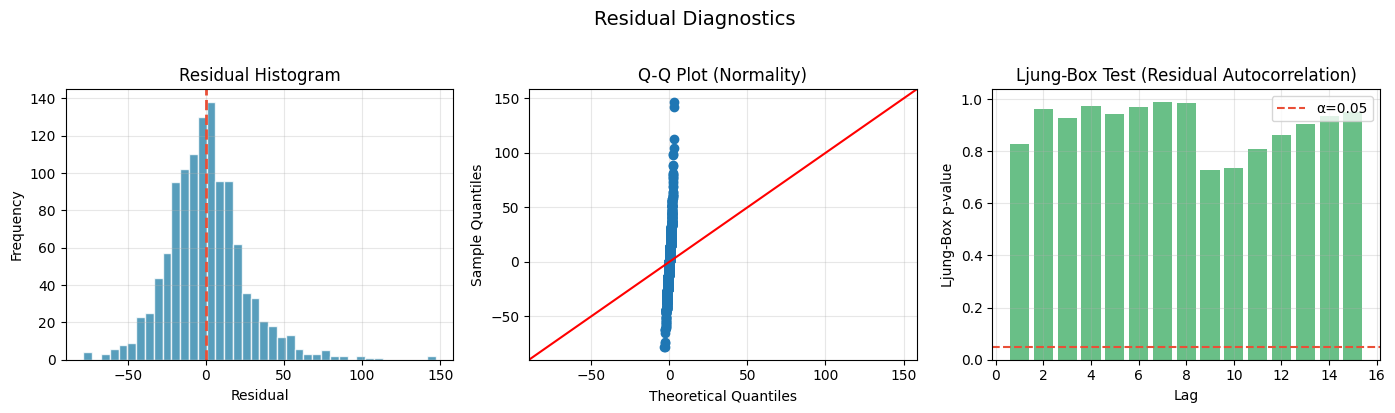

Đã lưu: E:\myself\GITHUB\pm25_sarima_project\reports\figures\04_eval\residual_diagnostics.png


In [8]:
residuals = np.asarray(model.resid()).flatten()
residuals = residuals[~np.isnan(residuals)]

LJUNGBOX_LAGS = 15
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram
axes[0].hist(residuals, bins=40, color="#2E86AB", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="#E94F37", linestyle="--", linewidth=2)
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Residual Histogram")
axes[0].grid(True, alpha=0.3)

# Q-Q plot
qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot (Normality)")
axes[1].grid(True, alpha=0.3)

# Ljung-Box p-values
lb_result = acorr_ljungbox(residuals, lags=range(1, LJUNGBOX_LAGS + 1), return_df=True)
lags = lb_result.index if hasattr(lb_result.index, "__len__") else range(1, LJUNGBOX_LAGS + 1)
axes[2].bar(lags, lb_result["lb_pvalue"], color="#44AF69", alpha=0.8)
axes[2].axhline(0.05, color="#E94F37", linestyle="--", label="α=0.05")
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("Ljung-Box p-value")
axes[2].set_title("Ljung-Box Test (Residual Autocorrelation)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Residual Diagnostics", fontsize=14, y=1.02)
plt.tight_layout()

diag_path = EVAL_FIG / "residual_diagnostics.png"
plt.savefig(diag_path, dpi=300, bbox_inches="tight")
plt.show()
print("Đã lưu:", diag_path)